Upload: models_catalog.csv, pricing_history.csv, capability_milestones.csv, compute_estimates.csv, benchmark_scores.csv


Saving benchmark_scores.csv to benchmark_scores (7).csv
Saving capability_milestones.csv to capability_milestones (5).csv
Saving compute_estimates.csv to compute_estimates (6).csv
Saving models_catalog.csv to models_catalog (6).csv
Saving pricing_history.csv to pricing_history (4).csv
PROJECT: LLM Industry Trends — Capability, Cost & Price
Models: 113 | Benchmarks: 1276 | Milestones: 57
Compute records: 113 | Pricing records: 1187
Master analysis table shape: (113, 20)


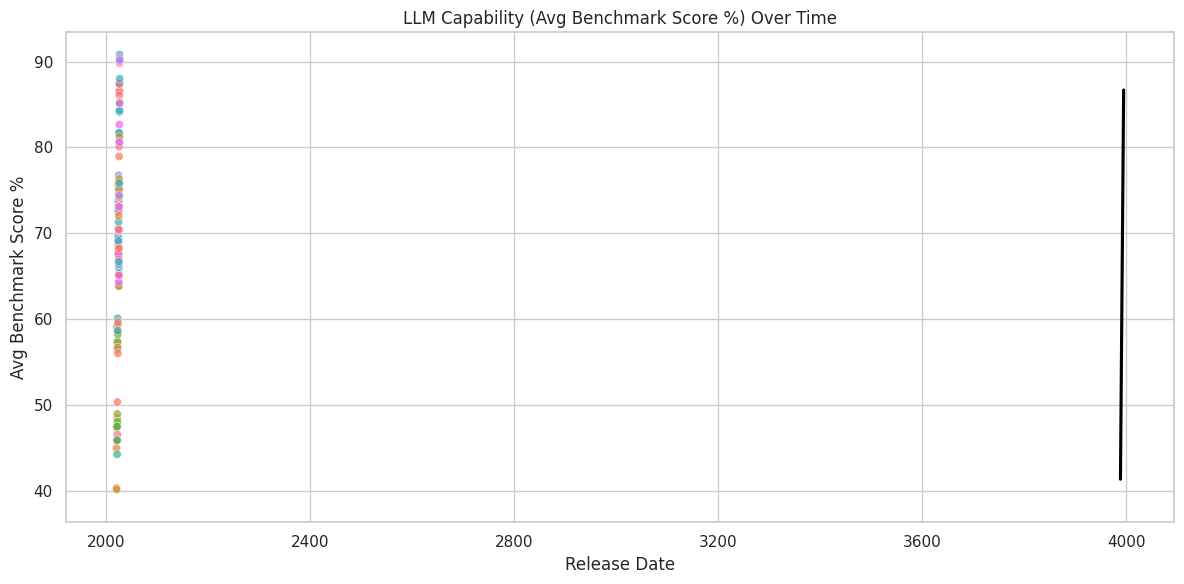

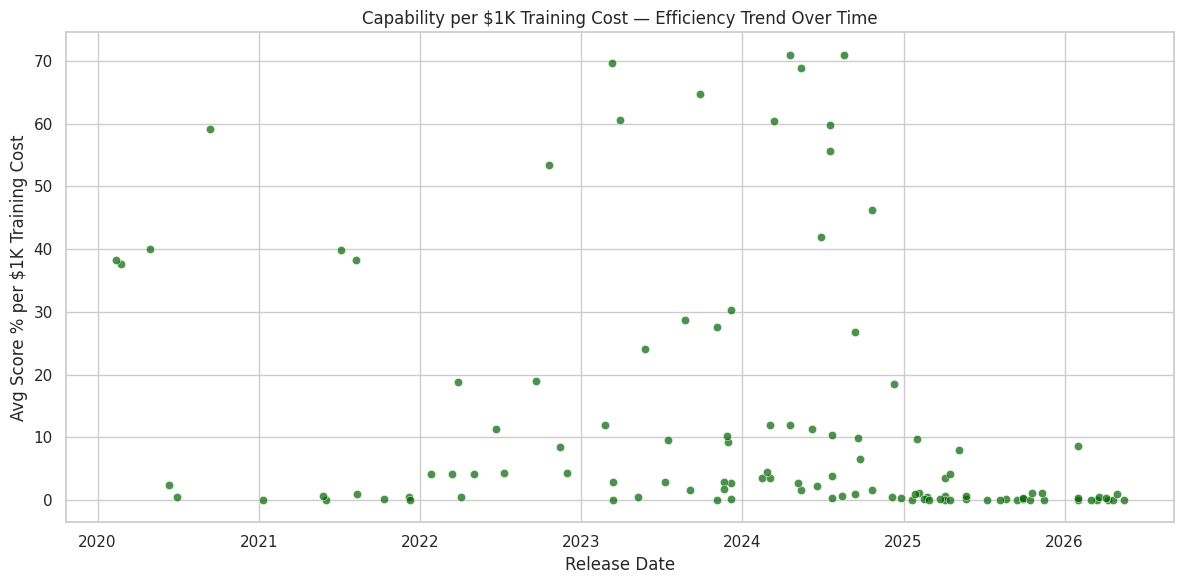

/tmp/ipykernel_1154/2062067863.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=master, x='access_type', y='avg_score_pct', palette='Set2')


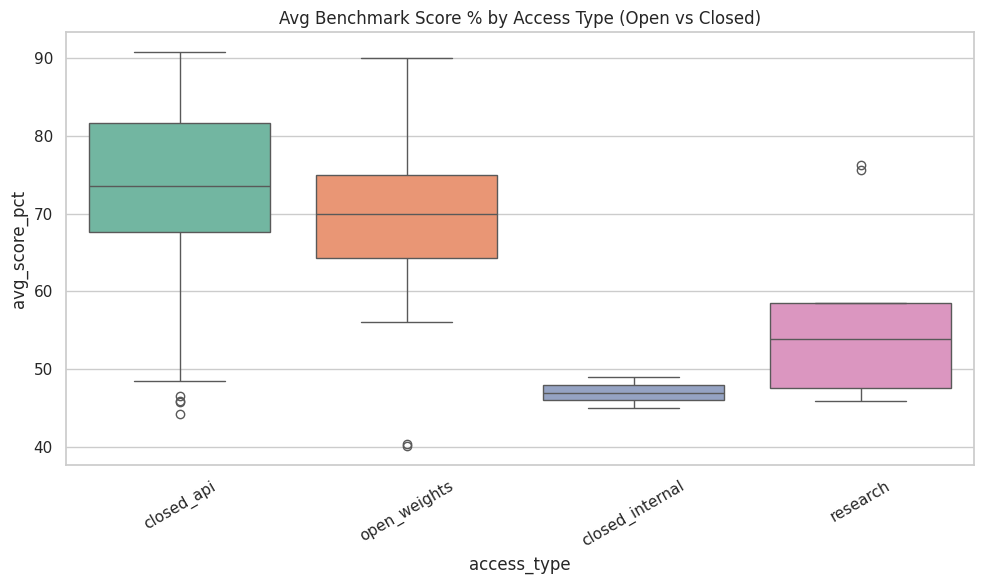

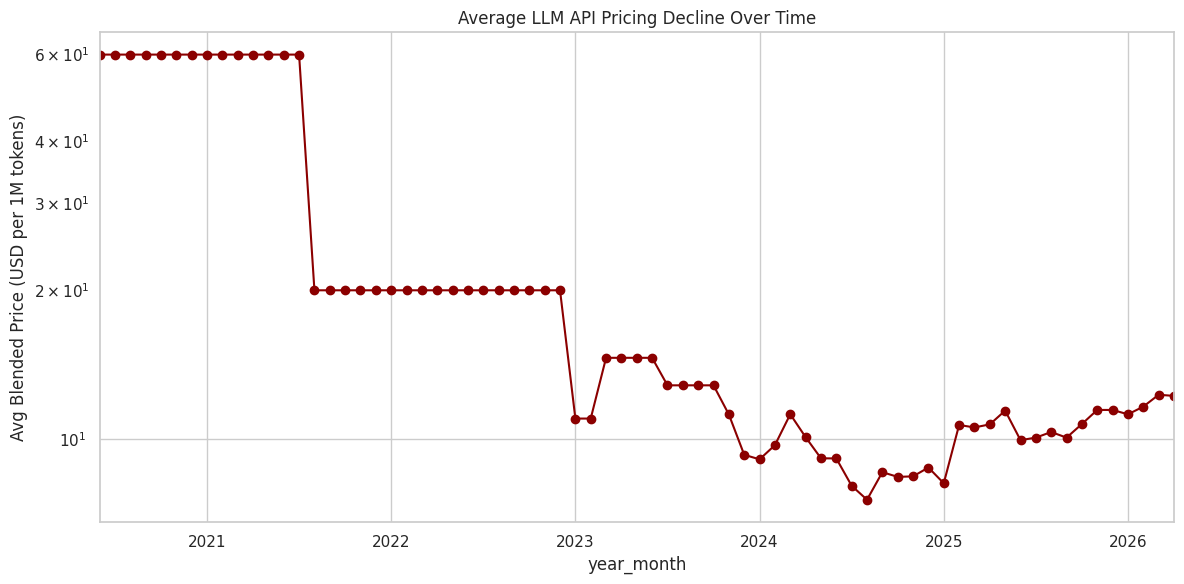

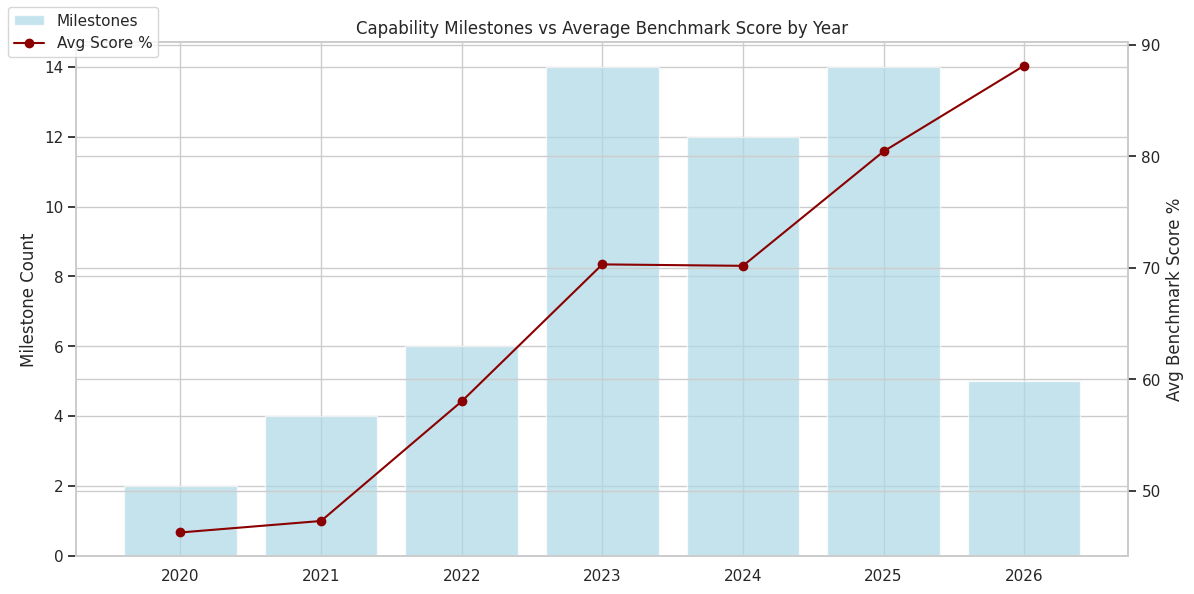

Linear Regression: RMSE=5.86, R2=0.7422
Random Forest: RMSE=6.12, R2=0.7183


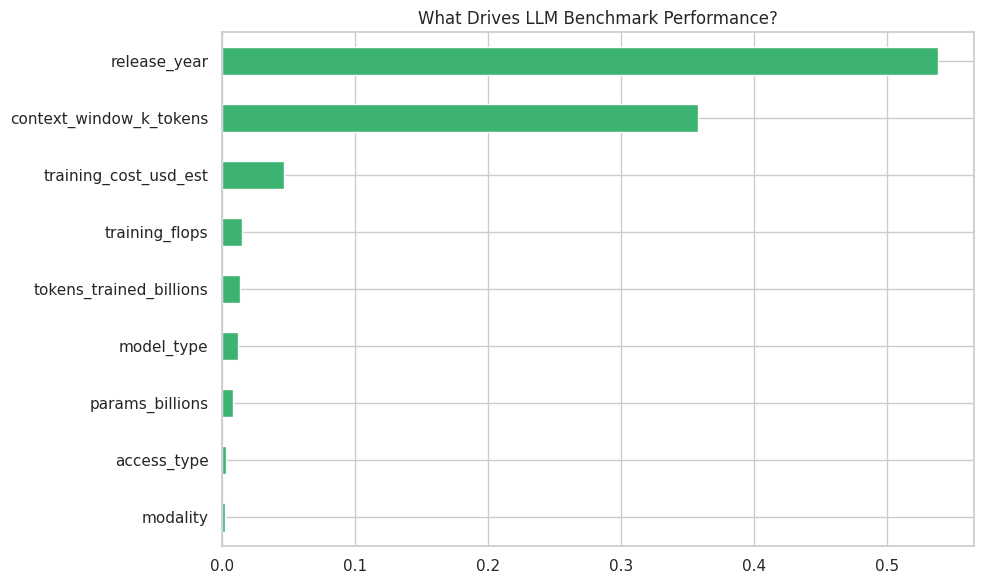

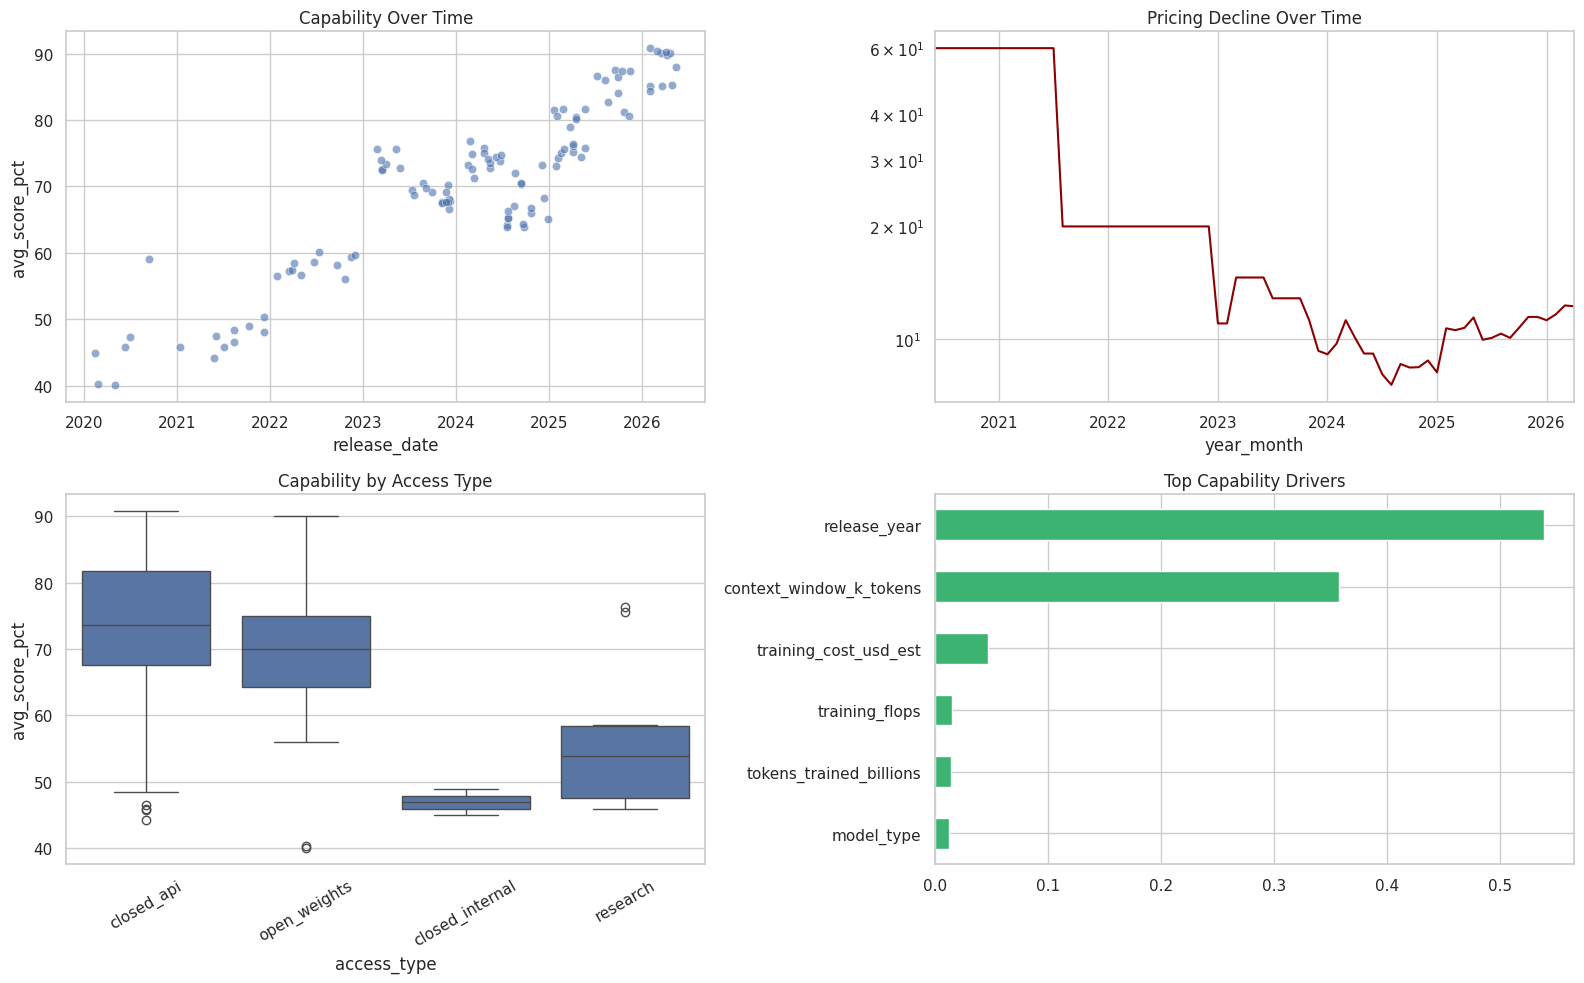

FINAL CONCLUSIONS — LLM INDUSTRY ANALYSIS

1. CAPABILITY GROWTH: Avg benchmark score rose from 46.3% (2020) to 88.1% (2026)

2. PRICE COLLAPSE: Avg API price fell from $60.00 to $12.23 per 1M tokens over the dataset period

3. ACCESS TYPE: closed_api models show the highest average capability

4. TOP CAPABILITY DRIVER: release_year (importance = 0.539)

5. PREDICTIVE POWER: Random Forest achieves R2 = 0.718 predicting benchmark score from model specs

6. MILESTONE ACTIVITY: Peak milestone year = 2023 (14 events)

RECOMMENDATION: Capability gains are increasingly decoupled from raw cost growth,
driven by efficiency improvements — confirming the industry's shift toward
smaller, smarter, cheaper models over brute-force scaling.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Task 4 Complete: End-to-end real-world LLM industry analysis finished.


In [8]:
# ===================================================
# TASK 4: REAL-WORLD DATA PROJECT
# Domain: AI/Tech Industry — LLM Capabilities & Economics
# End-to-end: Analysis + Prediction + Conclusions
# ===================================================

# %% Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# %% Step 2: Upload All 5 Files
from google.colab import files
print("Upload: models_catalog.csv, pricing_history.csv, capability_milestones.csv, compute_estimates.csv, benchmark_scores.csv")
uploaded = files.upload()

# %% Step 3: Load & Context
models = pd.read_csv("models_catalog.csv")
pricing = pd.read_csv("pricing_history.csv")
milestones = pd.read_csv("capability_milestones.csv")
compute = pd.read_csv("compute_estimates.csv")
benchmarks = pd.read_csv("benchmark_scores.csv")

print("="*60)
print("PROJECT: LLM Industry Trends — Capability, Cost & Price")
print("="*60)
print(f"Models: {models.shape[0]} | Benchmarks: {benchmarks.shape[0]} | Milestones: {milestones.shape[0]}")
print(f"Compute records: {compute.shape[0]} | Pricing records: {pricing.shape[0]}")

# %% Step 4: Clean & Parse Dates
for d in [models, compute, benchmarks]:
    d['release_date'] = pd.to_datetime(d['release_date'])
milestones['date'] = pd.to_datetime(milestones['date'])
pricing['year_month'] = pd.to_datetime(pricing['year_month'])

models = models.drop_duplicates()
compute = compute.drop_duplicates()
benchmarks = benchmarks.drop_duplicates()

# %% Step 5: Build Master Analysis Table
avg_score = benchmarks.groupby('model_id')['score_pct'].mean().reset_index().rename(columns={'score_pct': 'avg_score_pct'})

master = models.merge(compute[['model_id', 'tokens_trained_billions', 'training_flops',
                                 'gpu_hours_h100_equiv', 'training_cost_usd_est', 'energy_mwh', 'co2_tons_est']],
                        on='model_id', how='left')
master = master.merge(avg_score, on='model_id', how='left')

master = master.dropna(subset=['avg_score_pct'])
print("Master analysis table shape:", master.shape)

# %% Step 6: Capability Growth Over Time (Core Finding 1)
plt.figure(figsize=(12, 6))
sns.scatterplot(data=master, x='release_date', y='avg_score_pct', hue='organization', alpha=0.7, legend=False)
sns.regplot(data=master, x=master['release_date'].map(pd.Timestamp.toordinal), y='avg_score_pct', scatter=False, color='black')
plt.title("LLM Capability (Avg Benchmark Score %) Over Time")
plt.xlabel("Release Date")
plt.ylabel("Avg Benchmark Score %")
plt.tight_layout()
plt.savefig("capability_over_time.png", dpi=300)
plt.show()

# %% Step 7: Cost Efficiency — Performance per Training Dollar (Core Finding 2)
master['score_per_1k_usd'] = master['avg_score_pct'] / (master['training_cost_usd_est'] / 1000 + 1)

plt.figure(figsize=(12, 6))
sns.scatterplot(data=master, x='release_date', y='score_per_1k_usd', alpha=0.7, color='darkgreen')
plt.title("Capability per $1K Training Cost — Efficiency Trend Over Time")
plt.xlabel("Release Date")
plt.ylabel("Avg Score % per $1K Training Cost")
plt.tight_layout()
plt.savefig("cost_efficiency.png", dpi=300)
plt.show()

# %% Step 8: Open vs Closed Access — Capability Comparison (Core Finding 3)
plt.figure(figsize=(10, 6))
sns.boxplot(data=master, x='access_type', y='avg_score_pct', palette='Set2')
plt.title("Avg Benchmark Score % by Access Type (Open vs Closed)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("access_type_capability.png", dpi=300)
plt.show()

# %% Step 9: Pricing Decline Over Time (Core Finding 4)
plt.figure(figsize=(12, 6))
monthly_price = pricing.groupby('year_month')['blended_usd_per_1m_tokens'].mean()
monthly_price.plot(marker='o', color='darkred')
plt.title("Average LLM API Pricing Decline Over Time")
plt.ylabel("Avg Blended Price (USD per 1M tokens)")
plt.yscale('log')
plt.tight_layout()
plt.savefig("pricing_decline.png", dpi=300)
plt.show()

# %% Step 10: Milestone Density vs Capability Jumps (Core Finding 5)
milestones_per_year = milestones.groupby('year').size()
capability_per_year = master.groupby(master['release_date'].dt.year)['avg_score_pct'].mean()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(milestones_per_year.index, milestones_per_year.values, color='lightblue', alpha=0.7, label='Milestones')
ax1.set_ylabel("Milestone Count")
ax2 = ax1.twinx()
ax2.plot(capability_per_year.index, capability_per_year.values, color='darkred', marker='o', label='Avg Score %')
ax2.set_ylabel("Avg Benchmark Score %")
plt.title("Capability Milestones vs Average Benchmark Score by Year")
fig.legend(loc='upper left')
plt.tight_layout()
plt.savefig("milestones_vs_capability.png", dpi=300)
plt.show()

# %% Step 11: PREDICTIVE MODEL — Predict Avg Benchmark Score from Model Specs
model_features = ['params_billions', 'release_year', 'context_window_k_tokens',
                   'tokens_trained_billions', 'training_flops', 'training_cost_usd_est',
                   'model_type', 'access_type', 'modality']

df_pred = master[model_features + ['avg_score_pct']].copy()
for col in df_pred.select_dtypes(include=np.number).columns:
    df_pred[col] = df_pred[col].fillna(df_pred[col].median())

cat_cols = ['model_type', 'access_type', 'modality']
for col in cat_cols:
    le = LabelEncoder()
    df_pred[col] = le.fit_transform(df_pred[col].astype(str))

X = df_pred.drop(columns=['avg_score_pct'])
y = df_pred['avg_score_pct']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRegression().fit(X_train_scaled, y_train)
rf = RandomForestRegressor(n_estimators=150, random_state=42).fit(X_train_scaled, y_train)

for name, model in [("Linear Regression", lr), ("Random Forest", rf)]:
    pred = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f"{name}: RMSE={rmse:.2f}, R2={r2:.4f}")

# %% Step 12: Feature Importance for Capability Prediction
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='mediumseagreen')
plt.title("What Drives LLM Benchmark Performance?")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300)
plt.show()

# %% Step 13: Final Dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.scatterplot(data=master, x='release_date', y='avg_score_pct', ax=axes[0, 0], alpha=0.6)
axes[0, 0].set_title("Capability Over Time")

monthly_price.plot(ax=axes[0, 1], color='darkred')
axes[0, 1].set_yscale('log')
axes[0, 1].set_title("Pricing Decline Over Time")

sns.boxplot(data=master, x='access_type', y='avg_score_pct', ax=axes[1, 0])
axes[1, 0].set_title("Capability by Access Type")
axes[1, 0].tick_params(axis='x', rotation=30)

importances.head(6).plot(kind='barh', ax=axes[1, 1], color='mediumseagreen')
axes[1, 1].set_title("Top Capability Drivers")
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.savefig("final_dashboard.png", dpi=300)
plt.show()

# %% Step 14: Conclusions Report
print("="*70)
print("FINAL CONCLUSIONS — LLM INDUSTRY ANALYSIS")
print("="*70)
print(f"\n1. CAPABILITY GROWTH: Avg benchmark score rose from "
      f"{capability_per_year.iloc[0]:.1f}% ({capability_per_year.index[0]}) to "
      f"{capability_per_year.iloc[-1]:.1f}% ({capability_per_year.index[-1]})")
print(f"\n2. PRICE COLLAPSE: Avg API price fell from ${monthly_price.iloc[0]:.2f} to "
      f"${monthly_price.iloc[-1]:.2f} per 1M tokens over the dataset period")
print(f"\n3. ACCESS TYPE: {master.groupby('access_type')['avg_score_pct'].mean().idxmax()} models "
      f"show the highest average capability")
print(f"\n4. TOP CAPABILITY DRIVER: {importances.idxmax()} (importance = {importances.max():.3f})")
print(f"\n5. PREDICTIVE POWER: Random Forest achieves R2 = {r2_score(y_test, rf.predict(X_test_scaled)):.3f} "
      f"predicting benchmark score from model specs")
print(f"\n6. MILESTONE ACTIVITY: Peak milestone year = {milestones_per_year.idxmax()} "
      f"({milestones_per_year.max()} events)")
print("\nRECOMMENDATION: Capability gains are increasingly decoupled from raw cost growth,")
print("driven by efficiency improvements — confirming the industry's shift toward")
print("smaller, smarter, cheaper models over brute-force scaling.")
print("="*70)

# %% Step 15: Save & Download
import joblib
master.to_csv("llm_master_analysis.csv", index=False)
joblib.dump(rf, "capability_predictor.pkl")

files.download("llm_master_analysis.csv")
files.download("capability_predictor.pkl")
files.download("final_dashboard.png")

print("Task 4 Complete: End-to-end real-world LLM industry analysis finished.")